# Exploratory Data Analysis

This notebook explores patterns in the training data after the final holdout set has been separated.

All exploratory decisions in this notebook are based only on `X_train` and `y_train` to avoid information leakage from the final test set.

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


In [27]:
housing = fetch_openml(
    data_id=42165,
    as_frame=True
)

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1168, 80), (292, 80), (1168,), (292,))

## Target Distribution

We first inspect the target distribution in the training data only.

This helps determine whether `SalePrice` is symmetric or skewed and whether a transformation may be useful later.

In [28]:
y_train.describe()

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

In [29]:
y_train.skew()

np.float64(1.743128561420854)

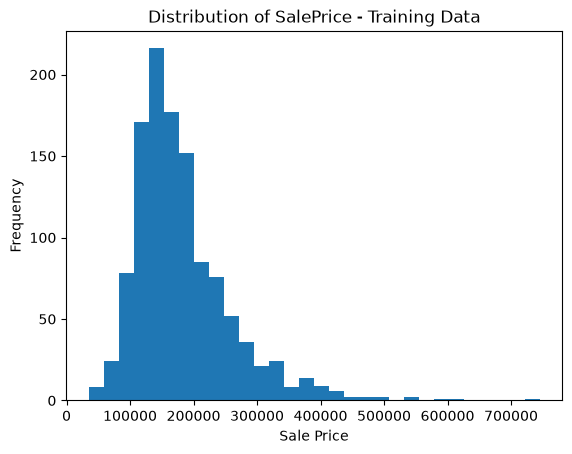

In [30]:
plt.Figure(figsize=(8, 5))
plt.hist(y_train, bins= 30)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice - Training Data")
plt.show()

### Log Transformation of the Target

Because `SalePrice` is strongly right-skewed, we test whether a logarithmic transformation makes the target distribution more symmetric.

The transformation is evaluated rather than assumed to be useful.

In [31]:
y_train_log = np.log1p(y_train)

In [32]:
y_train_log.skew()

np.float64(0.12489024367919238)

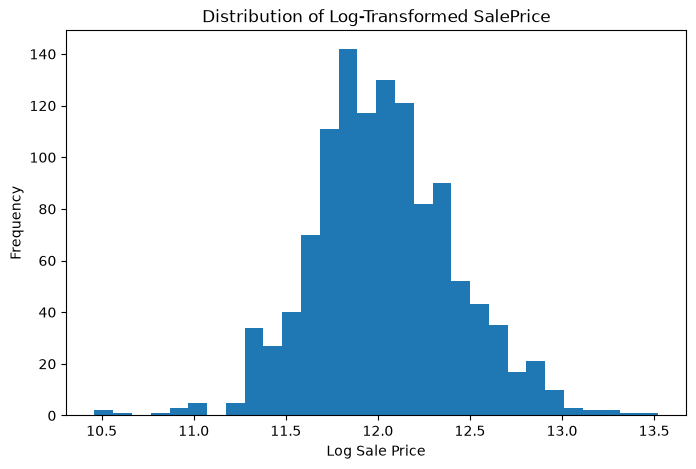

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(y_train_log, bins=30)
plt.xlabel("Log Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed SalePrice")
plt.show()

The original `SalePrice` distribution is strongly right-skewed, with a skewness of approximately 1.74.

After applying `log1p`, skewness decreases to approximately 0.12 and the distribution becomes substantially more symmetric.

The log-transformed target will therefore be considered as a candidate modeling target, but its usefulness must still be validated during model evaluation.

## Numerical Feature Relationships

We examine the linear relationship between numerical features and `SalePrice`
using Pearson correlation.

Correlation is used here as an exploratory screening tool, not as a measure of
causality or final feature importance.

In [34]:
numeric_train = X_train.select_dtypes(include="number")

numeric_train.shape

(1168, 37)

In [35]:
saleprice_correlations = numeric_train.corrwith(y_train)

saleprice_correlations.sort_values(ascending=False)

OverallQual      0.785555
GrLivArea        0.695652
GarageCars       0.640991
GarageArea       0.624139
TotalBsmtSF      0.597766
1stFlrSF         0.587883
FullBath         0.552546
TotRmsAbvGrd     0.520388
YearBuilt        0.516501
YearRemodAdd     0.508593
GarageYrBlt      0.480351
MasVnrArea       0.459123
Fireplaces       0.457549
BsmtFinSF1       0.359460
LotFrontage      0.330066
WoodDeckSF       0.329843
2ndFlrSF         0.314030
OpenPorchSF      0.299969
HalfBath         0.280481
LotArea          0.266204
BsmtFullBath     0.226346
BsmtUnfSF        0.222487
BedroomAbvGr     0.156211
ScreenPorch      0.119172
PoolArea         0.115630
3SsnPorch        0.051532
MoSold           0.041890
BsmtFinSF2      -0.005731
YrSold          -0.009099
LowQualFinSF    -0.011189
Id              -0.019643
MiscVal         -0.020179
BsmtHalfBath    -0.048346
OverallCond     -0.074391
MSSubClass      -0.088081
KitchenAbvGr    -0.142785
EnclosedPorch   -0.149532
dtype: float64

In [36]:
saleprice_correlations.abs().sort_values(ascending=False).head(10)

OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
dtype: float64

In [37]:
log_saleprice_correlations = numeric_train.corrwith(y_train_log)

log_saleprice_correlations.abs().sort_values(
    ascending = False
).head(10)

OverallQual     0.807946
GrLivArea       0.689012
GarageCars      0.684451
GarageArea      0.654520
TotalBsmtSF     0.597214
FullBath        0.583747
1stFlrSF        0.580948
YearBuilt       0.576725
YearRemodAdd    0.562152
GarageYrBlt     0.530321
dtype: float64

The strongest numerical relationships remain broadly stable after transforming
the target with `log1p`.

Several features, including `OverallQual`, `GarageCars`, `YearBuilt`, and
`YearRemodAdd`, show stronger linear associations with the log-transformed
target.

This suggests that the logarithmic transformation not only reduces target
skewness, but may also make some feature-target relationships more linear.

Correlation is used only as an exploratory screening tool and should not be
interpreted as causality or final feature importance.

### Visual Inspection of Strong Numerical Relationships

Correlation summarizes the strength of a linear relationship with a single number,
but it can hide non-linearity, outliers, and unusual patterns.

We therefore inspect three representative features visually:

- `OverallQual`: an ordinal quality rating
- `GrLivArea`: a continuous measure of living area
- `YearBuilt`: a temporal numerical feature

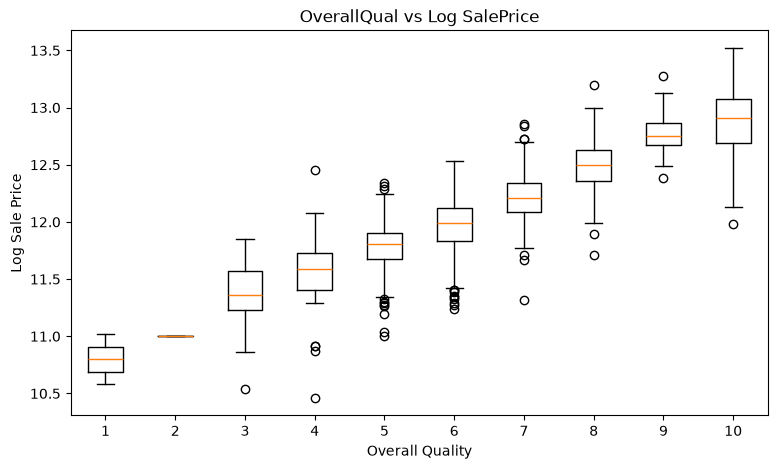

In [38]:
quality_levels = sorted(X_train["OverallQual"].dropna().unique())

quality_log_prices = [
    y_train_log[X_train["OverallQual"] == level]
    for level in quality_levels
]

plt.figure(figsize=(9, 5))
plt.boxplot(
    quality_log_prices,
    tick_labels=quality_levels
)

plt.xlabel("Overall Quality")
plt.ylabel("Log Sale Price")
plt.title("OverallQual vs Log SalePrice")
plt.show()

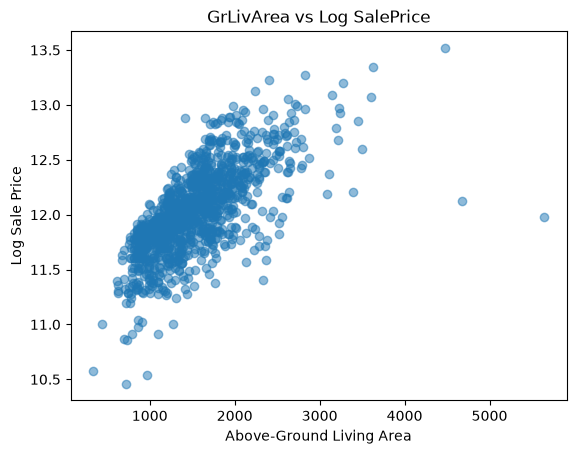

In [39]:
plt.Figure(figsize=(8, 5))

plt.scatter(
    X_train["GrLivArea"],
    y_train_log,
    alpha= 0.5
)


plt.xlabel("Above-Ground Living Area")
plt.ylabel("Log Sale Price")
plt.title("GrLivArea vs Log SalePrice")
plt.show()

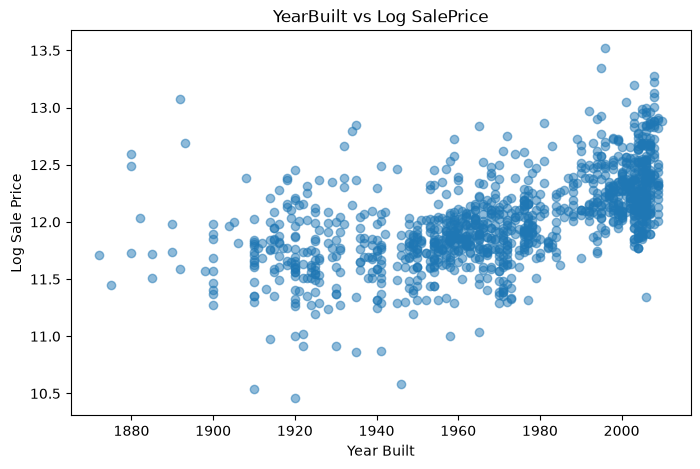

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train["YearBuilt"],
    y_train_log,
    alpha=0.5
)

plt.xlabel("Year Built")
plt.ylabel("Log Sale Price")
plt.title("YearBuilt vs Log SalePrice")
plt.show()

## Categorical Feature Relationships

Categorical features cannot be interpreted using ordinary numerical correlation.

Instead, we compare the distribution of the target across categories to identify
features whose groups show meaningful differences in sale price.

In [41]:
categorical_train = X_train.select_dtypes(exclude="number")
categorical_train.shape

(1168, 43)

In [42]:
categorical_cardinality = (
    categorical_train
    .nunique()
    .sort_values()
    )

categorical_cardinality

Street            2
Alley             2
CentralAir        2
Utilities         2
LandSlope         3
PoolQC            3
PavedDrive        3
GarageFinish      3
BsmtQual          4
ExterQual         4
MasVnrType        4
Electrical        4
KitchenQual       4
BsmtCond          4
BsmtExposure      4
Fence             4
MiscFeature       4
LandContour       4
LotShape          4
FireplaceQu       5
HeatingQC         5
GarageQual        5
GarageCond        5
MSZoning          5
LotConfig         5
BldgType          5
ExterCond         5
BsmtFinType1      6
RoofStyle         6
GarageType        6
Foundation        6
Heating           6
BsmtFinType2      6
SaleCondition     6
Functional        7
RoofMatl          7
HouseStyle        8
Condition2        8
SaleType          9
Condition1        9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64

In [43]:
eda_train = X_train.copy()
eda_train["LogSalePrice"] = y_train_log

In [44]:
neighborhood_price_summary = (
    eda_train.groupby("Neighborhood")["LogSalePrice"]
    .agg(["median", "count"])
    .sort_values("median", ascending= False)
)
neighborhood_price_summary

,median,count
Neighborhood,,
NridgHt,12.659737,61
NoRidge,12.577640,33
StoneBr,12.549565,20
Veenker,12.411056,9
Somerst,12.331387,69
Timber,12.329370,28
ClearCr,12.259618,19
Crawfor,12.247117,44
CollgCr,12.208575,115


`Neighborhood` shows substantial differences in median log sale price across
categories, suggesting that location contains important information for predicting
house prices.

However, some neighborhoods contain very few training observations, so their
group-level statistics should be interpreted cautiously.

In [45]:
eda_train["KitchenQual"].value_counts(dropna= False)

KitchenQual
TA    589
Gd    470
Ex     77
Fa     32
Name: count, dtype: int64

In [46]:
eda_train.groupby("KitchenQual")["LogSalePrice"].agg(
    ["median", "count"]
).sort_values(by= "median", ascending = False)

,median,count
KitchenQual,,
Ex,12.675767,77
Gd,12.216769,470
TA,11.842236,589
Fa,11.623605,32


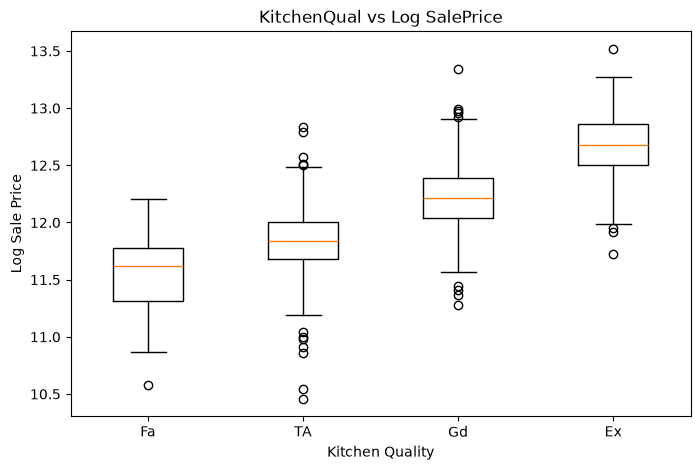

In [47]:
quality_order = ["Fa", "TA", "Gd", "Ex"]

kitchen_price_groups = [
    eda_train.loc[
        eda_train["KitchenQual"] == level,
        "LogSalePrice"
    ]
    for level in quality_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(
    kitchen_price_groups,
    tick_labels=quality_order
)

plt.xlabel("Kitchen Quality")
plt.ylabel("Log Sale Price")
plt.title("KitchenQual vs Log SalePrice")
plt.show()

### Relationships Among Strong Numerical Features

Several numerical features show strong relationships with the target, but some
of them may also contain overlapping information.

We examine correlations among the strongest numerical features to identify
potential redundancy and multicollinearity.

In [48]:
selected_numeric_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "YearBuilt",
    "YearRemodAdd"
]

In [49]:
feature_correlation_matrix = (
    X_train[selected_numeric_features]
    .corr()
    .round(2)
)

feature_correlation_matrix

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd
OverallQual,1.00,0.58,0.59,0.55,0.53,0.46,0.54,0.56,0.54
GrLivArea,0.58,1.00,0.47,0.48,0.45,0.56,0.62,0.17,0.28
GarageCars,0.59,0.47,1.00,0.88,0.44,0.44,0.47,0.53,0.41
GarageArea,0.55,0.48,0.88,1.00,0.49,0.49,0.41,0.47,0.36
TotalBsmtSF,0.53,0.45,0.44,0.49,1.00,0.83,0.31,0.39,0.29
1stFlrSF,0.46,0.56,0.44,0.49,0.83,1.00,0.36,0.27,0.23
FullBath,0.54,0.62,0.47,0.41,0.31,0.36,1.00,0.46,0.45
YearBuilt,0.56,0.17,0.53,0.47,0.39,0.27,0.46,1.00,0.59
YearRemodAdd,0.54,0.28,0.41,0.36,0.29,0.23,0.45,0.59,1.00


Several predictor pairs show strong correlations.

The strongest relationships are observed between `GarageCars` and `GarageArea`,
and between `TotalBsmtSF` and `1stFlrSF`, suggesting that these feature pairs
contain partially overlapping information.

High predictor correlation may introduce redundancy and, particularly in linear
models, potential multicollinearity.

No features are removed at this stage; any feature-selection decision should be
evaluated during model validation.

In [50]:
train_missing_summary = (
    X_train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

train_missing_summary[train_missing_summary > 0]

PoolQC          99.486301
MiscFeature     96.061644
Alley           93.664384
Fence           80.051370
FireplaceQu     46.832192
LotFrontage     18.578767
GarageType       5.479452
GarageYrBlt      5.479452
GarageQual       5.479452
GarageCond       5.479452
GarageFinish     5.479452
BsmtCond         2.397260
BsmtFinType2     2.397260
BsmtFinType1     2.397260
BsmtQual         2.397260
BsmtExposure     2.397260
MasVnrArea       0.513699
MasVnrType       0.513699
Electrical       0.085616
dtype: float64

The missing-value pattern in the training data remains broadly consistent with
the pattern observed in the full dataset.

For example, structurally sparse features such as `PoolQC`, `MiscFeature`,
`Alley`, and `Fence` still show very high missing rates, while `LotFrontage`
remains moderately missing.

No major shift in missingness is observed after the train/test split.

## EDA Summary

The training data shows several important patterns:

- `SalePrice` is strongly right-skewed. Applying `log1p` reduces skewness from
  approximately 1.74 to 0.12 and produces a substantially more symmetric target.
- `OverallQual`, `GrLivArea`, garage-related features, basement area, and building
  age show strong relationships with the target.
- Visual inspection confirms clear positive relationships while also revealing
  unusual observations that correlation alone cannot identify.
- Categorical features such as `Neighborhood` and `KitchenQual` contain meaningful
  price information.
- `KitchenQual` shows a clear positive ordinal relationship with sale price.
- Strong correlations between `GarageCars` and `GarageArea`, and between
  `TotalBsmtSF` and `1stFlrSF`, indicate partially redundant predictor information.
- Missing-value patterns in the training set remain broadly consistent with those
  observed during initial data understanding.

No preprocessing or feature removal decisions are made solely from EDA.
These findings will guide candidate preprocessing strategies that must later be
evaluated through validation.